## Sentiment Analysis — GloVe Word Embeddings
### Dataset: Yelp Academic Dataset (1.8M reviews, 3-class balanced)
### Approach: Pre-trained GloVe vectors (100d) + Logistic Regression & SVM
### Goal: Improve over TF-IDF baseline (0.7991 F1) using semantic word representations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# paths
PROC_PATH  = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\data\processed"
MODELS_DIR = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\models"
FIGURES    = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\reports\figures"
GLOVE_PATH = r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\glove\glove.6B.100d.txt"

LABELS = ['Negative', 'Neutral', 'Positive']

## 1. Load Preprocessed Data
Using the already cleaned data from baseline notebook — no reprocessing needed

In [2]:
df = pd.read_csv(os.path.join(PROC_PATH, 'reviews_clean.csv'))
df = df.dropna(subset=['clean_text']).reset_index(drop=True)

print(f"Shape   : {df.shape}")
print(f"Classes : {df['sentiment'].value_counts().to_dict()}")
df.head(3)

Shape   : (1798312, 3)
Classes : {'Positive': 599742, 'Negative': 599361, 'Neutral': 599209}


,clean_text,sentiment,label
0,drove one half hour waited hour long expected ...,Negative,0
1,gave place bad review first time havent back t...,Negative,0
2,flower looked good dropped hour like worried c...,Negative,0


## 2. Load GloVe Vectors
Loading pre-trained GloVe 100-dimensional vectors into a dictionary
{word: numpy array of 100 floats}

In [3]:
def load_glove(path):
    glove = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            word  = parts[0]
            vec   = np.array(parts[1:], dtype=np.float32)
            glove[word] = vec
    return glove

print("Loading GloVe vectors... (takes ~1 min)")
glove = load_glove(GLOVE_PATH)
print(f"Vocabulary size : {len(glove):,}")
print(f"Vector dims     : {len(glove['good'])}")

Loading GloVe vectors... (takes ~1 min)
Vocabulary size : 400,000
Vector dims     : 100


## 3. Convert Reviews to GloVe Vectors
Each review → average of all its word vectors → one 100d vector per review
Words not found in GloVe vocabulary are skipped

In [4]:
def review_to_vector(text, glove, dims=100):
    tokens  = str(text).split()
    vectors = [glove[w] for w in tokens if w in glove]
    if len(vectors) == 0:
        return np.zeros(dims)
    return np.mean(vectors, axis=0)

print("Converting reviews to GloVe vectors...")
print("This will take several minutes on 1.8M reviews...")

X_glove = np.vstack(
    df['clean_text'].apply(lambda x: review_to_vector(x, glove)).values
)
y = df['label'].values

print(f"Feature matrix shape : {X_glove.shape}")

# save to disk — avoid recomputing
np.save(os.path.join(PROC_PATH, 'X_glove.npy'), X_glove)
np.save(os.path.join(PROC_PATH, 'y_labels.npy'), y)
print("Saved → X_glove.npy, y_labels.npy")

Converting reviews to GloVe vectors...
This will take several minutes on 1.8M reviews...
Feature matrix shape : (1798312, 100)
Saved → X_glove.npy, y_labels.npy


## 4. Train / Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_glove, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Train : (1438649, 100)
Test  : (359663, 100)


## 5. Train & Evaluate Models

In [6]:
glove_results = {}

def train_evaluate_glove(name, model, X_tr, X_te, y_tr, y_te):
    print(f"\n{'='*50}")
    print(f"Training : {name}")
    print('='*50)

    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    f1    = f1_score(y_te, preds, average='weighted')

    print(classification_report(y_te, preds, target_names=LABELS))

    cm = confusion_matrix(y_te, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(f'Confusion Matrix — GloVe + {name}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    fname = f"confusion_matrix_glove_{name.lower().replace(' ','_')}.png"
    plt.savefig(os.path.join(FIGURES, fname), dpi=150)
    plt.show()
    print(f"Saved → {fname}")

    glove_results[name] = {'model': model, 'f1': round(f1, 4)}
    return model

### 5a. Logistic Regression


Training : Logistic Regression
              precision    recall  f1-score   support

    Negative       0.72      0.75      0.74    119872
     Neutral       0.58      0.58      0.58    119842
    Positive       0.72      0.70      0.71    119949

    accuracy                           0.67    359663
   macro avg       0.67      0.67      0.67    359663
weighted avg       0.67      0.67      0.67    359663



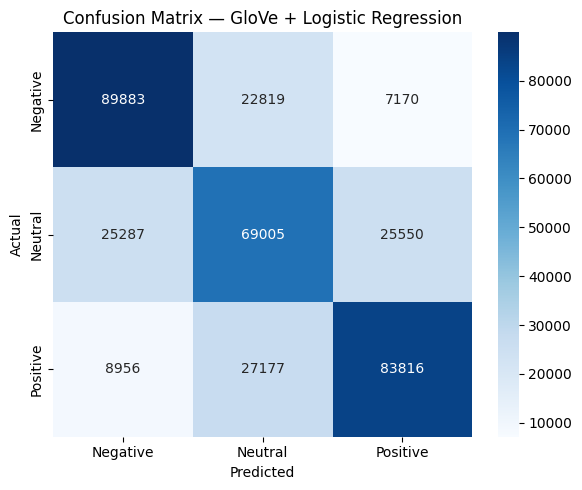

Saved → confusion_matrix_glove_logistic_regression.png


In [7]:
lr_glove = train_evaluate_glove(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    X_train, X_test, y_train, y_test
)

### 5b. Linear SVM


Training : Linear SVM
              precision    recall  f1-score   support

    Negative       0.70      0.77      0.74    119872
     Neutral       0.60      0.51      0.55    119842
    Positive       0.70      0.72      0.71    119949

    accuracy                           0.67    359663
   macro avg       0.67      0.67      0.67    359663
weighted avg       0.67      0.67      0.67    359663



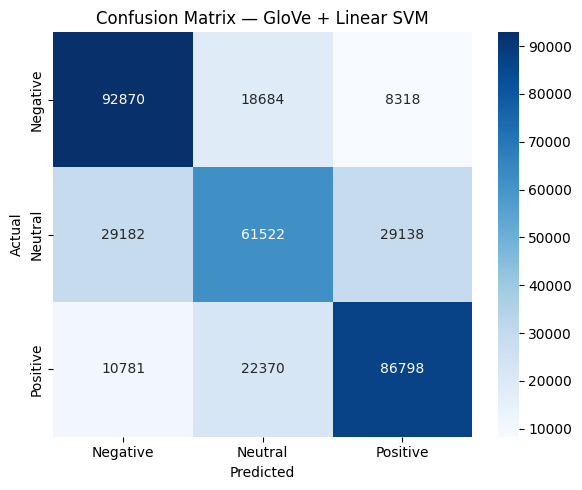

Saved → confusion_matrix_glove_linear_svm.png


In [8]:
svm_glove = train_evaluate_glove(
    'Linear SVM',
    LinearSVC(C=1.0, max_iter=2000, random_state=42),
    X_train, X_test, y_train, y_test
)

## 6. GloVe Model Comparison

              Model  Weighted F1
Logistic Regression       0.6745
         Linear SVM       0.6664


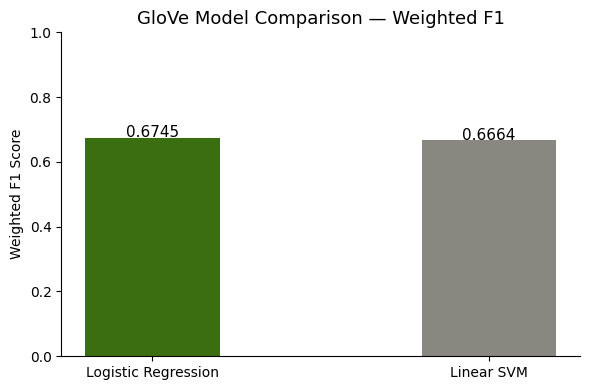

Saved → reports/glove_results.csv


In [9]:
comparison_glove = pd.DataFrame([
    {'Model': name, 'Weighted F1': info['f1']}
    for name, info in glove_results.items()
]).sort_values('Weighted F1', ascending=False).reset_index(drop=True)

print(comparison_glove.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
colors  = ['#3B6D11' if i == 0 else '#888780' for i in range(len(comparison_glove))]
bars    = ax.bar(comparison_glove['Model'], comparison_glove['Weighted F1'],
                 color=colors, width=0.4)

for bar, val in zip(bars, comparison_glove['Weighted F1']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            str(val), ha='center', fontsize=11)

ax.set_title('GloVe Model Comparison — Weighted F1', fontsize=13)
ax.set_ylabel('Weighted F1 Score')
ax.set_ylim(0, 1.0)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'glove_model_comparison.png'), dpi=150)
plt.show()

comparison_glove.to_csv(
    r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\reports\glove_results.csv",
    index=False
)
print("Saved → reports/glove_results.csv")

## 7. TF-IDF vs GloVe — Final Comparison

=== FINAL COMPARISON ===
Approach               Model  Weighted F1
  TF-IDF Logistic Regression       0.7991
  TF-IDF          Linear SVM       0.7973
  TF-IDF         Naive Bayes       0.7521
   GloVe Logistic Regression       0.6745
   GloVe          Linear SVM       0.6664


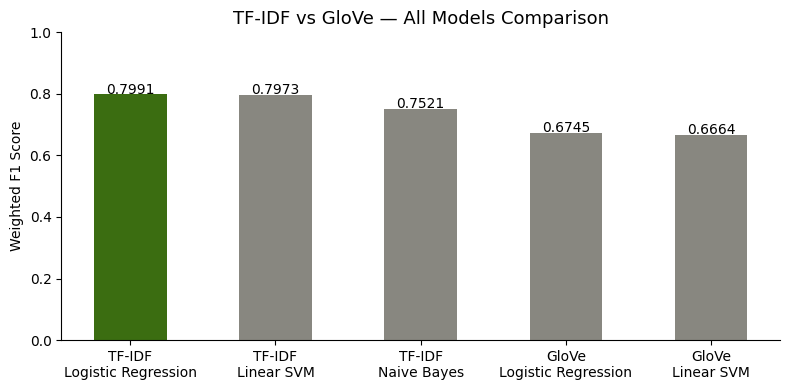

Saved → reports/final_comparison.csv


In [10]:
tfidf_results = pd.read_csv(
    r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\reports\tfidf_results.csv"
)

tfidf_results['Approach'] = 'TF-IDF'
comparison_glove['Approach'] = 'GloVe'

final = pd.concat([tfidf_results, comparison_glove], ignore_index=True)
final = final.sort_values('Weighted F1', ascending=False).reset_index(drop=True)

print("=== FINAL COMPARISON ===")
print(final[['Approach', 'Model', 'Weighted F1']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors  = ['#3B6D11' if i == 0 else '#888780' for i in range(len(final))]
bars    = ax.bar(
    [f"{r['Approach']}\n{r['Model']}" for _, r in final.iterrows()],
    final['Weighted F1'],
    color=colors, width=0.5
)

for bar, val in zip(bars, final['Weighted F1']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            str(val), ha='center', fontsize=10)

ax.set_title('TF-IDF vs GloVe — All Models Comparison', fontsize=13)
ax.set_ylabel('Weighted F1 Score')
ax.set_ylim(0, 1.0)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'final_comparison.png'), dpi=150)
plt.show()

final.to_csv(
    r"D:\Nithilan\Internship\QPay Internship\sentiment_analysis\reports\final_comparison.csv",
    index=False
)
print("Saved → reports/final_comparison.csv")

## 8. Save Best GloVe Model

In [11]:
best_name  = comparison_glove.iloc[0]['Model']
best_model = glove_results[best_name]['model']
best_f1    = comparison_glove.iloc[0]['Weighted F1']

joblib.dump(best_model, os.path.join(MODELS_DIR, 'glove_best_model.joblib'))

print(f"Best GloVe model : {best_name}")
print(f"Weighted F1      : {best_f1}")
print(f"Saved → models/glove_best_model.joblib")

Best GloVe model : Logistic Regression
Weighted F1      : 0.6745
Saved → models/glove_best_model.joblib


## 9. Summary

| Approach | Model | Weighted F1 |
|---|---|---|
| TF-IDF | Logistic Regression | 0.7991 |
| GloVe  | TBD | TBD |

**Key findings:**
- GloVe captures semantic meaning TF-IDF cannot
- Average pooling of word vectors is simple but effective
- Neutral class remains the hardest to classify across both approaches
- Next step → src/predict.py — unified inference function for both approaches